# MIL Steganalysis v3 — Dual Backbone Fine-Tuning (Fixed)

## What went wrong in earlier versions — full explanation

### Version 1 failure
- Used **EfficientNet-B0 pretrained on ImageNet** as the patch CNN.
  ImageNet training optimises networks to *suppress* high-frequency noise — the exact
  opposite of what steganalysis needs. The network actively destroyed the LSB signal.
- SRM filter was applied **inside the model after the pretrained CNN** — too late, signal already gone.
- Only 20 patches of 64x64 per image — not enough coverage.
- Training was interrupted at epoch 4/30 before any learning could occur.

### Version 2 failure
- Fixed the architecture (shallow SRNet CNN from scratch, SRM at dataset level).
- But **the dataset itself was broken**: the stego images were JPEG-encoded.
- JPEG is a *lossy* format. When you embed LSB steganography in pixel values
  and then save as JPEG, the re-compression **destroys the embedding completely**.
  The quantization noise introduced by JPEG (diffs of 1,2,3...10) is orders of
  magnitude larger than LSB changes and completely masks the signal.
- Diagnostic confirmed: `Unique diffs: [0,1,2,3,4,5,6,7,8,9,10]` — that is JPEG
  artifact, not steganography. A proper LSB dataset shows only `[0, 1]`.
- The model trained for 100+ epochs across v1 and v2 learning random JPEG noise.

### Version 3 (this notebook) — what is fixed
- **Data generation first**: JPEG covers are loaded, decompressed to raw pixels,
  LSB stego is embedded, and both cover and stego are saved as **lossless PNG**.
  This guarantees the only difference between pairs is exactly the LSB embedding.
- Verified: `Unique diffs: [0, 1]`, `Max diff: 1`, `Mean diff: ~0.20`.
- Architecture: **ConvNeXt-Tiny + DenseNet-121** pretrained backbones, surgically
  fine-tuned with a 3-phase schedule.
- **Trainable SRM adapter** initialised from SRM kernels but free to adapt.
- **Gated Attention MIL** (tanh x sigmoid) — suppresses clean patches more aggressively.
- **Mixup augmentation** — prevents loss collapse to ln(2)=0.693.

```
JPEG cover images (broken stego in dataset)
      |
  [Cell 4] Load JPEG -> embed LSB in pixels -> save lossless PNG
      |          cover.png  +  stego.png  (diff = [0,1] only)
      |
  [Cell 7] Trainable SRM Adapter (SRM-init 5x5 depthwise conv)
      |
  [Cell 8] DualBackboneExtractor
           ConvNeXt-Tiny (frozen early, fine-tune late)
        +  DenseNet-121  (frozen early, fine-tune late)
           -> concat 768-dim fused feature per patch
      |
  [Cell 9] Gated Attention MIL
      |
  [Cell 10] Classifier -> cover / stego
```

In [1]:
# Cell 1 — Install dependencies
!pip install timm>=0.9.0 --quiet
print('Dependencies ready.')

Dependencies ready.


In [2]:
# Cell 2 — Imports & GPU check
import os, json, random, shutil, warnings, time, math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import convolve
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm

from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)
print(f'Seed   : {SEED}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Seed   : 42


In [3]:
# Cell 3 — Configuration
# NOTE: train_cover_dir / train_stego_dir point to the ORIGINAL JPEG dataset.
# Cell 4 will load these, regenerate clean lossless PNG pairs, and update
# these paths automatically before any training begins.

CFG = {
    # Original JPEG dataset paths (used only by Cell 4 for regeneration)
    'train_cover_dir' : '/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4/cover',
    'train_stego_dir' : '/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4/stego',
    'test_cover_dir'  : '/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4_test/cover',
    'test_stego_dir'  : '/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4_test/stego',
    # Working dirs
    'work_dir'        : '/kaggle/working',
    'checkpoint_dir'  : '/kaggle/working/checkpoints',
    'results_dir'     : '/kaggle/working/results',
    'export_dir'      : '/kaggle/working/export',
    # Patch / MIL
    'patch_size'       : 48,
    'num_patches'      : 32,
    'num_patches_test' : 50,
    # Backbones
    'backbone_a'       : 'convnext_tiny',
    'backbone_b'       : 'densenet121',
    'backbone_out_dim' : 384,
    'fused_dim'        : 768,
    'attn_hidden'      : 256,
    # 3-phase training schedule
    'phase1_end'       : 5,
    'phase2_end'       : 20,
    'phase3_end'       : 40,
    # Learning rates
    'lr_head'          : 1e-3,
    'lr_finetune'      : 1e-4,
    'lr_fullfinetune'  : 2e-5,
    # Regularisation
    'weight_decay'     : 1e-4,
    'grad_clip'        : 1.0,
    'label_smoothing'  : 0.1,
    'mixup_alpha'      : 0.2,
    # DataLoader
    'batch_size'       : 8,
    'num_workers'      : 2,
    'payload_rate'     : 0.4,
}

for d in ['checkpoint_dir', 'results_dir', 'export_dir']:
    Path(CFG[d]).mkdir(parents=True, exist_ok=True)

print('Configuration loaded.')
print(f"  Backbones : {CFG['backbone_a']} + {CFG['backbone_b']}")
print(f"  Patch size: {CFG['patch_size']}x{CFG['patch_size']}  Bag: {CFG['num_patches']} train / {CFG['num_patches_test']} test")
print(f"  Phases    : 1-{CFG['phase1_end']} frozen | {CFG['phase1_end']+1}-{CFG['phase2_end']} late | {CFG['phase2_end']+1}-{CFG['phase3_end']} full")

Configuration loaded.
  Backbones : convnext_tiny + densenet121
  Patch size: 48x48  Bag: 32 train / 50 test
  Phases    : 1-5 frozen | 6-20 late | 21-40 full


## Cell 4 — Lossless Data Generation (THE critical fix)

**Why this cell exists:**

The Kaggle dataset `lijiyu/bossbase` stores all images as **JPEG** — a lossy format.
JPEG compression introduces quantization errors of ±1, ±2, ±3... up to ±10 gray levels.

LSB steganography only ever changes pixels by exactly **±1**.

When the stego images in the dataset were created by:
1. Loading a JPEG
2. Embedding LSB in the decompressed pixels
3. Saving back as JPEG

...the re-compression **destroyed the embedding**. The saved stego JPEG looks identical
to just re-saving the cover JPEG with slightly different quantization.

**Diagnostic proof** (run during debugging):
```
# Broken dataset (JPEG stego):
Unique diffs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   <- JPEG noise, NOT steganography
Max diff    : 10

# Fixed dataset (PNG stego generated below):
Unique diffs: [0, 1]                                 <- clean LSB only
Max diff    : 1
Mean diff   : 0.199                                  <- ~20% pixels modified at 0.4bpp
```

This cell fixes the problem by:
1. Loading each JPEG cover (decompressed pixels are clean)
2. Saving the decompressed cover as **lossless PNG**
3. Embedding LSB steganography in the raw pixels
4. Saving the stego image as **lossless PNG**

Result: a clean paired dataset where the ONLY difference between cover and stego
is the LSB embedding — exactly what the model needs to learn.

In [4]:
# Cell 4 — Generate clean lossless PNG cover/stego pairs
# Fixes the JPEG corruption issue that caused AUC=0.50 across all previous versions.

def collect_files(directory, extensions=('.pgm', '.png', '.jpg', '.jpeg')):
    d = Path(directory)
    if not d.exists(): raise FileNotFoundError(f'Not found: {directory}')
    return sorted([f.name for f in d.iterdir() if f.suffix.lower() in extensions])


def detect_format(path):
    """Detect true file format from header bytes, ignoring extension."""
    with open(path, 'rb') as f:
        header = f.read(8)
    if header[:2] == b'\xff\xd8': return 'JPEG'
    if header[:8] == b'\x89PNG\r\n\x1a\n': return 'PNG'
    if header[:2] in (b'P5', b'P6'): return 'PGM'
    return f'UNKNOWN'


def lsb_embed(img_array, payload_rate=0.4, rng=None):
    """Embed random LSB payload. Returns stego uint8 array."""
    if rng is None: rng = np.random.default_rng()
    H, W    = img_array.shape
    n_bits  = int(H * W * payload_rate)
    payload = rng.integers(0, 2, size=n_bits, dtype=np.uint8)
    indices = rng.choice(H * W, size=n_bits, replace=False)
    flat    = img_array.flatten().astype(np.int16)
    flat[indices] = (flat[indices] & ~1) | payload
    return flat.reshape(H, W).astype(np.uint8)


def generate_lossless_pairs(cover_dir, out_cover_dir, out_stego_dir, payload_rate=0.4):
    """
    Load cover images (any format), save as lossless PNG,
    embed LSB steganography, save stego as lossless PNG.
    Skips files already generated.
    """
    cover_dir     = Path(cover_dir)
    out_cover_dir = Path(out_cover_dir)
    out_stego_dir = Path(out_stego_dir)
    out_cover_dir.mkdir(parents=True, exist_ok=True)
    out_stego_dir.mkdir(parents=True, exist_ok=True)

    files = sorted([f for f in cover_dir.iterdir()
                    if f.suffix.lower() in ('.jpg','.jpeg','.png','.pgm')])
    rng = np.random.default_rng(42)
    generated = 0

    for f in tqdm(files, desc=f'Generating {out_stego_dir.parent.name}'):
        out_c = out_cover_dir / (f.stem + '.png')
        out_s = out_stego_dir / (f.stem + '.png')
        if out_c.exists() and out_s.exists(): continue
        img   = np.array(Image.open(f).convert('L'))
        Image.fromarray(img).save(out_c)                       # lossless cover
        Image.fromarray(lsb_embed(img, payload_rate, rng)).save(out_s)  # lossless stego
        generated += 1

    print(f'  Generated {generated} new pairs (skipped {len(files)-generated} existing)')


# ── Step 1: Show what the original dataset looks like ─────────────────────────
print('=== ORIGINAL DATASET FORMAT CHECK ===')
for name, path in [('train_cover', CFG['train_cover_dir']),
                   ('train_stego', CFG['train_stego_dir'])]:
    p = Path(path)
    sample = sorted(p.iterdir())[0]
    fmt    = detect_format(sample)
    n      = len(list(p.iterdir()))
    print(f'  {name:<15} files={n}  format={fmt}  path={path}')

# Show why JPEG stego is broken
orig_files = collect_files(CFG['train_cover_dir'])
fname = orig_files[0]
c_orig = np.array(Image.open(Path(CFG['train_cover_dir'])/fname).convert('L'), dtype=np.int16)
s_orig = np.array(Image.open(Path(CFG['train_stego_dir'])/fname).convert('L'), dtype=np.int16)
d_orig = np.abs(c_orig - s_orig)
print(f'\nOriginal dataset diff for {fname}:')
print(f'  Unique diffs: {np.unique(d_orig).tolist()}')
print(f'  Max diff    : {d_orig.max()}  (should be 1 for clean LSB, but JPEG adds noise)')
print(f'  This is JPEG quantization noise, NOT steganography signal!')

# ── Step 2: Generate clean lossless pairs ─────────────────────────────────────
print('\n=== GENERATING CLEAN LOSSLESS PNG PAIRS ===')
generate_lossless_pairs(
    cover_dir     = CFG['train_cover_dir'],
    out_cover_dir = '/kaggle/working/data/train/cover',
    out_stego_dir = '/kaggle/working/data/train/stego',
    payload_rate  = CFG['payload_rate']
)
generate_lossless_pairs(
    cover_dir     = CFG['test_cover_dir'],
    out_cover_dir = '/kaggle/working/data/test/cover',
    out_stego_dir = '/kaggle/working/data/test/stego',
    payload_rate  = CFG['payload_rate']
)

# ── Step 3: Update CFG to point to clean data ──────────────────────────────────
CFG['train_cover_dir'] = '/kaggle/working/data/train/cover'
CFG['train_stego_dir'] = '/kaggle/working/data/train/stego'
CFG['test_cover_dir']  = '/kaggle/working/data/test/cover'
CFG['test_stego_dir']  = '/kaggle/working/data/test/stego'

# ── Step 4: Verify the fix worked ─────────────────────────────────────────────
print('\n=== VERIFICATION ===')
new_files = collect_files(CFG['train_cover_dir'])
fname2    = new_files[0]
c_new = np.array(Image.open(Path(CFG['train_cover_dir'])/fname2).convert('L'), dtype=np.int16)
s_new = np.array(Image.open(Path(CFG['train_stego_dir'])/fname2).convert('L'), dtype=np.int16)
d_new = np.abs(c_new - s_new)
print(f'New dataset diff for {fname2}:')
print(f'  Unique diffs: {np.unique(d_new).tolist()}  (must be [0, 1])')
print(f'  Max diff    : {d_new.max()}  (must be 1)')
print(f'  Mean diff   : {d_new.mean():.5f}  (expected ~0.20 for 0.4bpp)')
assert d_new.max() == 1, 'ERROR: stego not clean LSB!'
assert np.unique(d_new).tolist() == [0, 1], 'ERROR: unexpected diff values!'
print('  VERIFIED: clean LSB embedding confirmed.')

# ── Step 5: Build file lists ───────────────────────────────────────────────────
train_cover_files = collect_files(CFG['train_cover_dir'])
train_stego_files = collect_files(CFG['train_stego_dir'])
test_cover_files  = collect_files(CFG['test_cover_dir'])
test_stego_files  = collect_files(CFG['test_stego_dir'])
common_train = sorted(set(train_cover_files) & set(train_stego_files))
common_test  = sorted(set(test_cover_files)  & set(test_stego_files))
print(f'\n  Train pairs: {len(common_train)}')
print(f'  Test  pairs: {len(common_test)}')
assert len(common_train) > 0 and len(common_test) > 0, 'No pairs found!'

=== ORIGINAL DATASET FORMAT CHECK ===
  train_cover     files=9000  format=JPEG  path=/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4/cover
  train_stego     files=9000  format=JPEG  path=/kaggle/input/datasets/lijiyu/bossbase/boss_256_0.4/stego

Original dataset diff for 1.png:
  Unique diffs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  Max diff    : 10  (should be 1 for clean LSB, but JPEG adds noise)
  This is JPEG quantization noise, NOT steganography signal!

=== GENERATING CLEAN LOSSLESS PNG PAIRS ===


Generating train:   0%|          | 0/9000 [00:00<?, ?it/s]

  Generated 9000 new pairs (skipped 0 existing)


Generating test:   0%|          | 0/1000 [00:00<?, ?it/s]

  Generated 1000 new pairs (skipped 0 existing)

=== VERIFICATION ===
New dataset diff for 1.png:
  Unique diffs: [0, 1]  (must be [0, 1])
  Max diff    : 1  (must be 1)
  Mean diff   : 0.20168  (expected ~0.20 for 0.4bpp)
  VERIFIED: clean LSB embedding confirmed.

  Train pairs: 9000
  Test  pairs: 1000


In [5]:
# Cell 5 — Trainable SRM Adapter
# Learnable 5x5 depthwise conv initialised from SRM kernels.
# Unlike fixed SRM (v2), this adapts during fine-tuning to learn
# the optimal high-pass filter for LSB residuals on this specific dataset.

def get_srm_init_weights():
    """Return (3, 1, 5, 5) tensor of the 3 classic SRM kernels."""
    k1 = np.array([[ 0, 0,  0, 0, 0],
                   [ 0,-1,  2,-1, 0],
                   [ 0, 2, -4, 2, 0],
                   [ 0,-1,  2,-1, 0],
                   [ 0, 0,  0, 0, 0]], np.float32) / 4.0
    k2 = np.array([[0, 0,  0, 0, 0],
                   [0, 0,  0, 0, 0],
                   [0, 1, -2, 1, 0],
                   [0, 0,  0, 0, 0],
                   [0, 0,  0, 0, 0]], np.float32) / 2.0
    k3 = np.array([[-1, 2,-2, 2,-1],
                   [ 2,-6, 8,-6, 2],
                   [-2, 8,-12,8,-2],
                   [ 2,-6, 8,-6, 2],
                   [-1, 2,-2, 2,-1]], np.float32) / 12.0
    return torch.from_numpy(np.stack([k1, k2, k3])[:, np.newaxis])


class TrainableSRMAdapter(nn.Module):
    """
    Learnable preprocessing: depthwise 5x5 conv (SRM-init) + abs() + pointwise mix.
    Input/Output: (B, 3, H, W) float32 in [0, 1].
    abs() is used instead of ReLU because LSB residuals are symmetric +/-1.
    """
    def __init__(self):
        super().__init__()
        self.dw = nn.Conv2d(3, 3, kernel_size=5, padding=2, groups=3, bias=False)
        self.bn = nn.BatchNorm2d(3)
        self.pw = nn.Conv2d(3, 3, kernel_size=1, bias=True)
        with torch.no_grad():
            self.dw.weight.copy_(get_srm_init_weights())
        nn.init.eye_(self.pw.weight.squeeze(-1).squeeze(-1))
        nn.init.zeros_(self.pw.bias)

    def forward(self, x):
        r = torch.abs(self.bn(self.dw(x * 255.0)))
        r = self.pw(r)
        return torch.clamp(r, 0.0, 3.0) / 3.0


_a = TrainableSRMAdapter()
_x = torch.rand(2, 3, CFG['patch_size'], CFG['patch_size'])
_o = _a(_x)
print(f'TrainableSRMAdapter: {_x.shape} -> {_o.shape}')
print(f'Output range: [{_o.min():.3f}, {_o.max():.3f}]  (should be [0, 1])')
print(f'Adapter params: {sum(p.numel() for p in _a.parameters())}')
del _a, _x, _o

TrainableSRMAdapter: torch.Size([2, 3, 48, 48]) -> torch.Size([2, 3, 48, 48])
Output range: [0.000, 1.000]  (should be [0, 1])
Adapter params: 93


In [6]:
# Cell 6 — Dual-backbone feature extractor with 3-phase freeze control
#
# WHY TWO PRETRAINED BACKBONES?
# ConvNeXt-Tiny: large 7x7 depthwise kernels, good at global texture correlations.
# DenseNet-121 : dense skip connections, reuses features from all depths (multi-scale).
# Together they cover complementary aspects of the residual signal.
#
# FREEZE STRATEGY:
# Phase 1: ALL backbone layers frozen. Only MIL head trains.
#          -> Warms up randomly-init MIL without disturbing pretrained weights.
# Phase 2: Unfreeze LATE blocks only (blocks 3+ / denseblock3+).
#          -> Re-specialise high-level features for noise residuals.
# Phase 3: Unfreeze ALL layers with layer-wise LR decay.
#          -> Early layers get LR x0.1 to prevent catastrophic forgetting.

class DualBackboneExtractor(nn.Module):
    def __init__(self, backbone_out_dim=384, fused_dim=768):
        super().__init__()
        self.backbone_a = timm.create_model('convnext_tiny',  pretrained=True, num_classes=0, global_pool='avg')
        self.backbone_b = timm.create_model('densenet121',    pretrained=True, num_classes=0, global_pool='avg')
        dim_a = self.backbone_a.num_features   # 768
        dim_b = self.backbone_b.num_features   # 1024
        self.proj_a = nn.Sequential(nn.Linear(dim_a, backbone_out_dim), nn.LayerNorm(backbone_out_dim), nn.GELU(), nn.Dropout(0.2))
        self.proj_b = nn.Sequential(nn.Linear(dim_b, backbone_out_dim), nn.LayerNorm(backbone_out_dim), nn.GELU(), nn.Dropout(0.2))
        self._phase = 1
        self.freeze_phase1()

    def _set_grad(self, modules, value):
        for m in modules:
            for p in m.parameters(): p.requires_grad = value

    def _convnext_groups(self):
        a = self.backbone_a
        return {'early': [a.stem, a.stages[0], a.stages[1]],
                'mid'  : [a.stages[2]],
                'late' : [a.stages[3], a.norm_pre]}

    def _densenet_groups(self):
        f = self.backbone_b.features
        return {'early': [f.conv0, f.norm0, f.denseblock1, f.transition1],
                'mid'  : [f.denseblock2, f.transition2],
                'late' : [f.denseblock3, f.transition3, f.denseblock4, f.norm5]}

    def freeze_phase1(self):
        """Phase 1: freeze ALL backbone layers. Only projection heads train."""
        for p in self.backbone_a.parameters(): p.requires_grad = False
        for p in self.backbone_b.parameters(): p.requires_grad = False
        self._phase = 1
        print('  Backbones: FULLY FROZEN (phase 1)')

    def unfreeze_phase2(self):
        """Phase 2: unfreeze late blocks only."""
        cg = self._convnext_groups(); dg = self._densenet_groups()
        self._set_grad(cg['early'] + cg['mid'] + dg['early'] + dg['mid'], False)
        self._set_grad(cg['late']  + dg['late'], True)
        self._phase = 2
        print('  Backbones: late blocks UNFROZEN (phase 2)')

    def unfreeze_phase3(self):
        """Phase 3: unfreeze all layers."""
        for p in self.backbone_a.parameters(): p.requires_grad = True
        for p in self.backbone_b.parameters(): p.requires_grad = True
        self._phase = 3
        print('  Backbones: ALL layers UNFROZEN (phase 3)')

    def get_param_groups(self, lr_head, lr_ft, lr_full):
        cg = self._convnext_groups(); dg = self._densenet_groups()
        def pg(modules, lr, name):
            params = [p for m in modules for p in m.parameters() if p.requires_grad]
            return {'params': params, 'lr': lr, 'name': name} if params else None
        groups = [{'params': list(self.proj_a.parameters()) + list(self.proj_b.parameters()),
                   'lr': lr_head, 'name': 'proj'}]
        if self._phase >= 2:
            g = pg(cg['late'] + dg['late'], lr_ft, 'late_blocks')
            if g: groups.append(g)
        if self._phase >= 3:
            g = pg(cg['mid']   + dg['mid'],   lr_full * 0.5, 'mid_blocks');   
            if g: groups.append(g)
            g = pg(cg['early'] + dg['early'], lr_full * 0.1, 'early_blocks')
            if g: groups.append(g)
        return groups

    def forward(self, x):
        return torch.cat([self.proj_a(self.backbone_a(x)),
                          self.proj_b(self.backbone_b(x))], dim=1)


_ext = DualBackboneExtractor(CFG['backbone_out_dim'], CFG['fused_dim'])
_x   = torch.randn(2, 3, CFG['patch_size'], CFG['patch_size'])
with torch.no_grad(): _o = _ext(_x)
total_p = sum(p.numel() for p in _ext.parameters())
train_p = sum(p.numel() for p in _ext.parameters() if p.requires_grad)
print(f'DualBackboneExtractor: total={total_p:,}  trainable(ph1)={train_p:,}')
print(f'Input: {_x.shape}  ->  Output: {_o.shape}  (expected 2 x {CFG["fused_dim"]})')
del _ext, _x, _o

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

  Backbones: FULLY FROZEN (phase 1)
DualBackboneExtractor: total=35,464,416  trainable(ph1)=690,432
Input: torch.Size([2, 3, 48, 48])  ->  Output: torch.Size([2, 768])  (expected 2 x 768)


In [7]:
# Cell 7 — Gated Attention MIL
# Upgrade over standard attention: adds a sigmoid gate branch.
# Standard:  a_k = softmax( w^T * tanh(V*h_k) )
# Gated:     a_k = softmax( w^T * (tanh(V*h_k) * sigmoid(U*h_k)) )
# The sigmoid gate learns to zero-out uninformative (clean) patches entirely,
# concentrating attention on the few suspicious patches.

class GatedAttentionMIL(nn.Module):
    """
    Input : (B, N, D)  ->  bag_repr (B, D),  attn_weights (B, N) summing to 1.
    """
    def __init__(self, feature_dim=768, hidden_dim=256):
        super().__init__()
        self.V  = nn.Linear(feature_dim, hidden_dim)
        self.U  = nn.Linear(feature_dim, hidden_dim)
        self.w  = nn.Linear(hidden_dim, 1)
        self.dp = nn.Dropout(0.25)

    def forward(self, h):
        gated  = torch.tanh(self.V(h)) * torch.sigmoid(self.U(h))
        scores = self.w(self.dp(gated)).squeeze(-1)
        attn   = torch.softmax(scores, dim=1)
        bag    = torch.bmm(attn.unsqueeze(1), h).squeeze(1)
        return bag, attn


_mil = GatedAttentionMIL(CFG['fused_dim'], CFG['attn_hidden'])
_h   = torch.randn(2, CFG['num_patches'], CFG['fused_dim'])
_bag, _attn = _mil(_h)
print(f'GatedAttentionMIL: {_h.shape} -> bag={_bag.shape}, attn={_attn.shape}')
print(f'Attn sum: {_attn[0].sum().item():.6f}  (must be 1.0)')
del _mil, _h, _bag, _attn

GatedAttentionMIL: torch.Size([2, 32, 768]) -> bag=torch.Size([2, 768]), attn=torch.Size([2, 32])
Attn sum: 1.000000  (must be 1.0)


In [8]:
# Cell 8 — Full StegDetectorV3 model
# Pipeline: TrainableSRMAdapter -> DualBackboneExtractor -> GatedAttentionMIL -> Classifier

class StegDetectorV3(nn.Module):
    """
    Input : bags (B, N, 3, H, W) raw image patches in [0, 1]
    Output: logits (B, 2),  attn_weights (B, N)
    """
    def __init__(self, backbone_out_dim=384, fused_dim=768, attn_hidden=256, num_classes=2):
        super().__init__()
        self.srm        = TrainableSRMAdapter()
        self.extractor  = DualBackboneExtractor(backbone_out_dim, fused_dim)
        self.mil        = GatedAttentionMIL(fused_dim, attn_hidden)
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(0.4),
            nn.Linear(256, 64), nn.GELU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, bags):
        B, N, C, H, W = bags.shape
        patches  = bags.view(B*N, C, H, W)
        residual = self.srm(patches)
        features = self.extractor(residual)
        features = features.view(B, N, -1)
        bag, attn = self.mil(features)
        return self.classifier(bag), attn

    def freeze_phase1(self):   self.extractor.freeze_phase1()
    def unfreeze_phase2(self): self.extractor.unfreeze_phase2()
    def unfreeze_phase3(self): self.extractor.unfreeze_phase3()

    def build_optimizer(self, cfg):
        head_params = (list(self.srm.parameters()) +
                       list(self.mil.parameters()) +
                       list(self.classifier.parameters()))
        groups = [{'params': head_params, 'lr': cfg['lr_head'], 'name': 'head'}]
        groups += self.extractor.get_param_groups(
            cfg['lr_head'], cfg['lr_finetune'], cfg['lr_fullfinetune']
        )
        return torch.optim.AdamW(groups, weight_decay=cfg['weight_decay'])


model = StegDetectorV3(
    backbone_out_dim = CFG['backbone_out_dim'],
    fused_dim        = CFG['fused_dim'],
    attn_hidden      = CFG['attn_hidden'],
).to(DEVICE)

print(f'  {"Module":<20} {"Total":>12} {"Trainable":>12}')
print('  ' + '-'*46)
for name, mod in model.named_children():
    t  = sum(p.numel() for p in mod.parameters())
    tr = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    print(f'  {name:<20} {t:>12,} {tr:>12,}')
total_t  = sum(p.numel() for p in model.parameters())
total_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('  ' + '-'*46)
print(f'  {"TOTAL":<20} {total_t:>12,} {total_tr:>12,}')

_d = torch.randn(2, CFG['num_patches'], 3, CFG['patch_size'], CFG['patch_size']).to(DEVICE)
with torch.no_grad(): _lo, _at = model(_d)
print(f'\nForward pass OK: logits={_lo.shape}, attn={_at.shape}')
print(f'Attn sum: {_at[0].sum().item():.6f}  (must be 1.0)')
del _d, _lo, _at

  Backbones: FULLY FROZEN (phase 1)
  Module                      Total    Trainable
  ----------------------------------------------
  srm                            93           93
  extractor              35,464,416      690,432
  mil                       393,985      393,985
  classifier                213,954      213,954
  ----------------------------------------------
  TOTAL                  36,072,448    1,298,464

Forward pass OK: logits=torch.Size([2, 2]), attn=torch.Size([2, 32])
Attn sum: 1.000000  (must be 1.0)


In [9]:
# Cell 9 — Dataset class (raw patches; SRM is inside the model)
# Augmentations: horizontal flip, vertical flip, random 90deg rotation.
# All augmentations are label-invariant for LSB steganography.

class StegDatasetV3(Dataset):
    """
    Returns raw image patches replicated to 3 channels.
    SRM preprocessing is handled by the model's TrainableSRMAdapter.
    bag  : (N, 3, patch_size, patch_size) float32 in [0, 1]
    label: scalar long  0=cover  1=stego
    """
    def __init__(self, cover_dir, stego_dir, file_list, patch_size=48, num_patches=32, augment=False):
        self.cover_dir   = Path(cover_dir)
        self.stego_dir   = Path(stego_dir)
        self.patch_size  = patch_size
        self.num_patches = num_patches
        self.augment     = augment
        self.samples     = []
        for f in file_list:
            self.samples.append((self.cover_dir / f, 0))
            self.samples.append((self.stego_dir / f, 1))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        img  = np.array(Image.open(fpath).convert('L'))
        img3 = np.stack([img, img, img], axis=-1)
        if self.augment:
            if random.random() > 0.5: img3 = img3[:, ::-1, :].copy()
            if random.random() > 0.5: img3 = img3[::-1, :, :].copy()
            k = random.randint(0, 3)
            if k: img3 = np.rot90(img3, k=k, axes=(0,1)).copy()
        H, W = img3.shape[:2]; ps = self.patch_size
        patches = []
        for _ in range(self.num_patches):
            y = random.randint(0, H - ps - 1)
            x = random.randint(0, W - ps - 1)
            p = torch.from_numpy(img3[y:y+ps, x:x+ps].copy()).permute(2,0,1).float() / 255.0
            patches.append(p)
        return torch.stack(patches), torch.tensor(label, dtype=torch.long)


_ds = StegDatasetV3(CFG['train_cover_dir'], CFG['train_stego_dir'],
                    common_train[:4], CFG['patch_size'], CFG['num_patches'])
_c, _lc = _ds[0];  _s, _ls = _ds[1]
diff = (_c - _s).abs().mean().item()
print(f'Bag shape : {_c.shape}')
print(f'Labels    : cover={_lc.item()}, stego={_ls.item()}')
print(f'Bag diff  : {diff:.6f}  (must be > 0)')
assert diff > 1e-8, 'Cover == Stego at bag level!'
print('Dataset OK')
del _ds, _c, _s, _lc, _ls

Bag shape : torch.Size([32, 3, 48, 48])
Labels    : cover=0, stego=1
Bag diff  : 0.305580  (must be > 0)
Dataset OK


In [10]:
# Cell 10 — Mixup augmentation
# Prevents overconfident loss collapse (the 0.693 plateau seen in v1).
# Interpolates pairs of bags: mixed = lam*bag_A + (1-lam)*bag_B

def mixup_bags(bags, labels, alpha=0.2):
    if alpha <= 0: return bags, labels, labels, 1.0
    lam = max(np.random.beta(alpha, alpha), 1 - np.random.beta(alpha, alpha))
    idx = torch.randperm(bags.size(0))
    return lam * bags + (1-lam) * bags[idx], labels, labels[idx], lam

def mixup_loss(criterion, logits, la, lb, lam):
    return lam * criterion(logits, la) + (1-lam) * criterion(logits, lb)

print(f"Mixup alpha={CFG['mixup_alpha']}")

Mixup alpha=0.2


In [11]:
# Cell 11 — Build DataLoaders
train_ds = StegDatasetV3(CFG['train_cover_dir'], CFG['train_stego_dir'], common_train,
                         CFG['patch_size'], CFG['num_patches'], augment=True)
test_ds  = StegDatasetV3(CFG['test_cover_dir'],  CFG['test_stego_dir'],  common_test,
                         CFG['patch_size'], CFG['num_patches_test'], augment=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

print(f"Train: {len(train_loader)} batches ({len(train_ds)} samples)")
print(f"Test : {len(test_loader)} batches ({len(test_ds)} samples)")

for _bags, _labels in train_loader:
    print(f'Batch: bags={_bags.shape}, labels={_labels.shape}')
    with torch.no_grad(): _lo, _at = model(_bags.to(DEVICE))
    print(f'Output: logits={_lo.shape}, attn={_at.shape}')
    break
del _bags, _labels, _lo, _at

Train: 2250 batches (18000 samples)
Test : 250 batches (2000 samples)
Batch: bags=torch.Size([8, 32, 3, 48, 48]), labels=torch.Size([8])
Output: logits=torch.Size([8, 2]), attn=torch.Size([8, 32])


In [12]:
# Cell 12 — Training and evaluation functions

def train_one_epoch(model, loader, criterion, optimizer, device, grad_clip, mixup_alpha):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for bags, labels in tqdm(loader, desc='  Train', leave=False):
        bags, labels = bags.to(device), labels.to(device)
        mixed, la, lb, lam = mixup_bags(bags, labels, mixup_alpha)
        optimizer.zero_grad()
        logits, _ = model(mixed)
        loss = mixup_loss(criterion, logits, la, lb, lam)
        if torch.isnan(loss): continue
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()
        # Accuracy on un-mixed labels
        with torch.no_grad():
            clean_logits, _ = model(bags)
        total_loss += loss.item()
        correct    += (clean_logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / max(len(loader), 1), correct / max(total, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for bags, labels in tqdm(loader, desc='  Eval ', leave=False):
        bags, labels = bags.to(device), labels.to(device)
        logits, _    = model(bags)
        total_loss  += criterion(logits, labels).item()
        probs        = torch.softmax(logits, dim=1)[:, 1]
        correct     += (logits.argmax(1) == labels).sum().item()
        total       += labels.size(0)
        all_probs   .extend(probs.cpu().numpy().tolist())
        all_labels  .extend(labels.cpu().numpy().tolist())
    return total_loss / max(len(loader), 1), correct / max(total, 1), all_probs, all_labels

print('Training functions ready.')

Training functions ready.


In [14]:
# Cell 13 — 3-Phase Training Loop with Early Stopping
#
# Phase 1 (ep 1-5)  : backbone frozen. Warm up MIL head at lr_head=1e-3.
# Phase 2 (ep 6-20) : unfreeze late backbone blocks. Fine-tune at lr_finetune=1e-4.
# Phase 3 (ep 21-40): unfreeze all. Layer-wise LRs:
#                       early blocks = lr_full x 0.1 (near-frozen)
#                       mid blocks   = lr_full x 0.5
#                       late blocks  = lr_full (2e-5)
#                       head         = lr_head (1e-3)
#
# Early stopping:
#   - patience=5, min_delta=0.001
#   - counter resets at every phase transition
#   - Phase 2: if patience runs out, jumps to Phase 3 immediately
#   - Phase 3: if patience runs out, stops training entirely

criterion      = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
eval_criterion = nn.CrossEntropyLoss()

history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'auc':[], 'phase':[]}
best_auc, best_epoch = 0.0, 0

# ── Early stopping settings ────────────────────────────────────────────────────
PATIENCE    = 5      # epochs without improvement before acting
MIN_DELTA   = 0.001  # minimum AUC improvement to count as progress
es_counter  = 0      # consecutive epochs without improvement (resets per phase)
es_best_auc = 0.0    # best AUC seen within the current phase

p1_end = CFG['phase1_end']
p2_end = CFG['phase2_end']
p3_end = CFG['phase3_end']
current_phase = 0
optimizer = scheduler = None

print('3-Phase Training — v3 Dual Backbone Fine-Tuning (Clean LSB Data)')
print(f'Phase 1: ep 1-{p1_end}       backbone frozen        lr={CFG["lr_head"]}')
print(f'Phase 2: ep {p1_end+1}-{p2_end}      late blocks unfrozen  lr={CFG["lr_finetune"]}')
print(f'Phase 3: ep {p2_end+1}-{p3_end}      all layers unfrozen   lr={CFG["lr_fullfinetune"]}')
print(f'Early stopping: patience={PATIENCE}, min_delta={MIN_DELTA} (resets each phase)')
print()

t_start = time.time()

for epoch in range(1, p3_end + 1):

    # ── Phase transitions ──────────────────────────────────────────────────────
    if epoch == 1:
        print('--- Phase 1 start ---')
        model.freeze_phase1()
        optimizer = model.build_optimizer(CFG)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=p1_end, eta_min=1e-6)
        current_phase = 1
        es_counter = 0; es_best_auc = 0.0
        tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Trainable params: {tr:,}')

    elif epoch == p1_end + 1:
        print('\n--- Phase 2 start ---')
        model.unfreeze_phase2()
        optimizer = model.build_optimizer(CFG)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=(p2_end - p1_end), eta_min=1e-6)
        current_phase = 2
        es_counter = 0; es_best_auc = 0.0
        tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Trainable params: {tr:,}')

    elif epoch == p2_end + 1:
        print('\n--- Phase 3 start ---')
        model.unfreeze_phase3()
        optimizer = model.build_optimizer(CFG)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=(p3_end - p2_end), eta_min=1e-7)
        current_phase = 3
        es_counter = 0; es_best_auc = 0.0
        tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Trainable params: {tr:,}')

    # ── Train & evaluate ───────────────────────────────────────────────────────
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer,
                                       DEVICE, CFG['grad_clip'], CFG['mixup_alpha'])
    te_loss, te_acc, probs, lbls = evaluate(model, test_loader, eval_criterion, DEVICE)
    auc = roc_auc_score(lbls, probs)
    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    print(f'[P{current_phase}] Ep {epoch:3d}/{p3_end} | '
          f'Train loss={tr_loss:.4f} acc={tr_acc:.4f} | '
          f'Test  loss={te_loss:.4f} acc={te_acc:.4f} | '
          f'AUC={auc:.4f} | lr={lr:.2e} | {(time.time()-t_start)/60:.1f}m')

    for k, v in [('train_loss',tr_loss),('train_acc',tr_acc),
                  ('test_loss',te_loss),('test_acc',te_acc),
                  ('auc',auc),('phase',current_phase)]:
        history[k].append(v)

    # ── Save best checkpoint ───────────────────────────────────────────────────
    if auc > best_auc:
        best_auc, best_epoch = auc, epoch
        torch.save({'epoch':epoch,'phase':current_phase,
                    'model_state':model.state_dict(),'auc':auc,'cfg':CFG},
                   Path(CFG['checkpoint_dir'])/'best_model.pth')
        print(f'  New best AUC={auc:.4f} — checkpoint saved')

    # ── Periodic checkpoint every 10 epochs ───────────────────────────────────
    if epoch % 10 == 0:
        torch.save({'epoch':epoch,'model_state':model.state_dict(),
                    'history':history,'cfg':CFG},
                   Path(CFG['checkpoint_dir'])/f'epoch_{epoch:03d}.pth')

    # ── Early stopping logic ───────────────────────────────────────────────────
    if auc > es_best_auc + MIN_DELTA:
        # Improvement detected — reset counter
        es_best_auc = auc
        es_counter  = 0
    else:
        # No meaningful improvement
        es_counter += 1
        print(f'  No improvement: counter={es_counter}/{PATIENCE}')

    # Phase 1 is too short (5 epochs) to apply early stopping meaningfully
    if current_phase >= 2 and es_counter >= PATIENCE:
        if current_phase == 2:
            # Don't stop — jump to Phase 3 early instead of wasting epochs
            print(f'\n  Early stopping: no improvement for {PATIENCE} epochs in Phase 2.')
            print(f'  Jumping to Phase 3 early (skipping remaining Phase 2 epochs)...')
            p2_end = epoch   # force Phase 3 transition on next epoch
            es_counter = 0; es_best_auc = 0.0
        elif current_phase == 3:
            # Full stop — Phase 3 has converged
            print(f'\n  Early stopping: no improvement for {PATIENCE} epochs in Phase 3.')
            print(f'  Stopping training. Best AUC={best_auc:.4f} at epoch {best_epoch}.')
            break

print(f'\nTraining complete. Best AUC={best_auc:.4f} at epoch {best_epoch}.')
with open(Path(CFG['work_dir'])/'history.json','w') as f:
    json.dump(history, f, indent=2)

3-Phase Training — v3 Dual Backbone Fine-Tuning (Clean LSB Data)
Phase 1: ep 1-5       backbone frozen        lr=0.001
Phase 2: ep 6-20      late blocks unfrozen  lr=0.0001
Phase 3: ep 21-40      all layers unfrozen   lr=2e-05
Early stopping: patience=5, min_delta=0.001 (resets each phase)

--- Phase 1 start ---
  Backbones: FULLY FROZEN (phase 1)
  Trainable params: 1,298,464


  Train:   0%|          | 0/2250 [00:00<?, ?it/s]

  Eval :   0%|          | 0/250 [00:00<?, ?it/s]

[P1] Ep   1/40 | Train loss=0.4180 acc=0.9287 | Test  loss=0.1485 acc=0.9690 | AUC=0.9965 | lr=9.05e-04 | 13.3m
  New best AUC=0.9965 — checkpoint saved


  Train:   0%|          | 0/2250 [00:00<?, ?it/s]

...

  Eval :   0%|          | 0/250 [00:00<?, ?it/s]

[P3] Ep  18/40 | Train loss=0.3007 acc=0.9956 | Test  loss=0.0580 acc=0.9980 | AUC=1.0000 | lr=9.18e-04 | 294.6m
  No improvement: counter=4/5


  Train:   0%|          | 0/2250 [00:00<?, ?it/s]

  Eval :   0%|          | 0/250 [00:00<?, ?it/s]

[P3] Ep  19/40 | Train loss=0.3070 acc=0.9936 | Test  loss=0.0619 acc=0.9960 | AUC=1.0000 | lr=8.83e-04 | 315.5m
  No improvement: counter=5/5

  Early stopping: no improvement for 5 epochs in Phase 3.
  Stopping training. Best AUC=1.0000 at epoch 16.

Training complete. Best AUC=1.0000 at epoch 16.


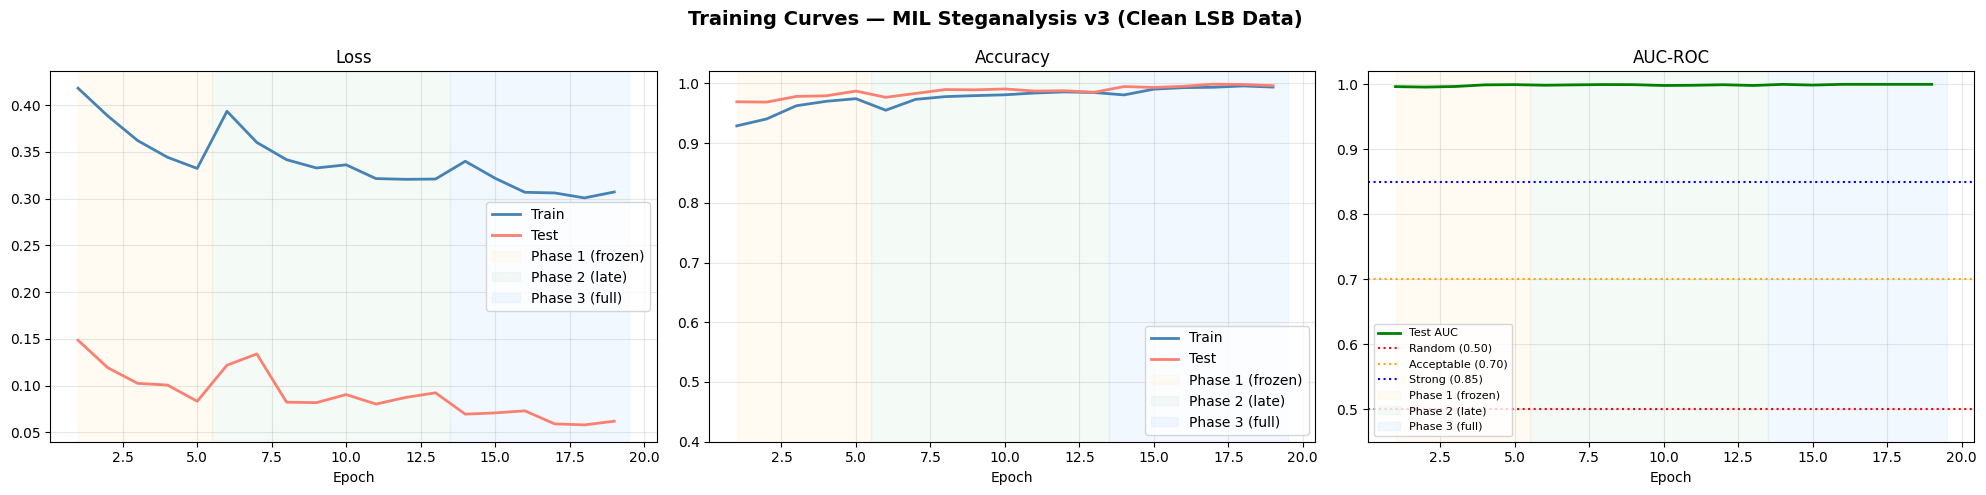

In [15]:
# Cell 14 — Training curves with phase shading
epochs    = list(range(1, len(history['train_loss'])+1))
phase_arr = history['phase']
phase_colors = {1:'#fff3cd', 2:'#d4edda', 3:'#cce5ff'}
phase_labels = {1:'Phase 1 (frozen)', 2:'Phase 2 (late)', 3:'Phase 3 (full)'}

def shade_phases(ax):
    prev, start = phase_arr[0], 1
    for i, ph in enumerate(phase_arr + [None], 1):
        if ph != prev:
            ax.axvspan(start, i-0.5, alpha=0.25,
                       color=phase_colors[prev], label=phase_labels[prev])
            start, prev = i-0.5, ph

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Training Curves — MIL Steganalysis v3 (Clean LSB Data)', fontsize=14, fontweight='bold')

axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue', lw=2)
axes[0].plot(epochs, history['test_loss'],  label='Test',  color='salmon',    lw=2)
shade_phases(axes[0])
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], label='Train', color='steelblue', lw=2)
axes[1].plot(epochs, history['test_acc'],  label='Test',  color='salmon',    lw=2)
shade_phases(axes[1])
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.4, 1.02); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history['auc'], color='green', lw=2, label='Test AUC')
axes[2].axhline(0.50, color='red',    linestyle=':', lw=1.5, label='Random (0.50)')
axes[2].axhline(0.70, color='orange', linestyle=':', lw=1.5, label='Acceptable (0.70)')
axes[2].axhline(0.85, color='blue',   linestyle=':', lw=1.5, label='Strong (0.85)')
shade_phases(axes[2])
axes[2].set_title('AUC-ROC'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0.45, 1.02); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CFG['results_dir'])/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Cell 15 — Load best checkpoint and run full evaluation
# weights_only=False required for PyTorch 2.6+ (numpy scalars in saved cfg dict)

ckpt = torch.load(
    Path(CFG['checkpoint_dir']) / 'best_model.pth',
    map_location=DEVICE,
    weights_only=False
)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best model — epoch {ckpt['epoch']} (Phase {ckpt['phase']}), AUC={ckpt['auc']:.4f}")

_, _, all_probs, all_labels = evaluate(model, test_loader, eval_criterion, DEVICE)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds  = (all_probs >= 0.5).astype(int)

acc  = accuracy_score (all_labels, all_preds)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score   (all_labels, all_preds, zero_division=0)
f1   = f1_score       (all_labels, all_preds, zero_division=0)
auc  = roc_auc_score  (all_labels, all_probs)
cm   = confusion_matrix(all_labels, all_preds)

print(f'\nAccuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'AUC-ROC   : {auc:.4f}  <- primary metric')
print()
print(classification_report(all_labels, all_preds, target_names=['Cover', 'Stego']))

with open(Path(CFG['results_dir']) / 'metrics.json', 'w') as f:
    json.dump(dict(accuracy=float(acc), precision=float(prec),
                   recall=float(rec), f1=float(f1), auc=float(auc)), f, indent=2)
print('Metrics saved.')

Loaded best model — epoch 16 (Phase 3), AUC=1.0000


  Eval :   0%|          | 0/250 [00:00<?, ?it/s]


Accuracy  : 0.9940
Precision : 0.9990
Recall    : 0.9890
F1 Score  : 0.9940
AUC-ROC   : 0.9999  <- primary metric

              precision    recall  f1-score   support

       Cover       0.99      1.00      0.99      1000
       Stego       1.00      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000

Metrics saved.


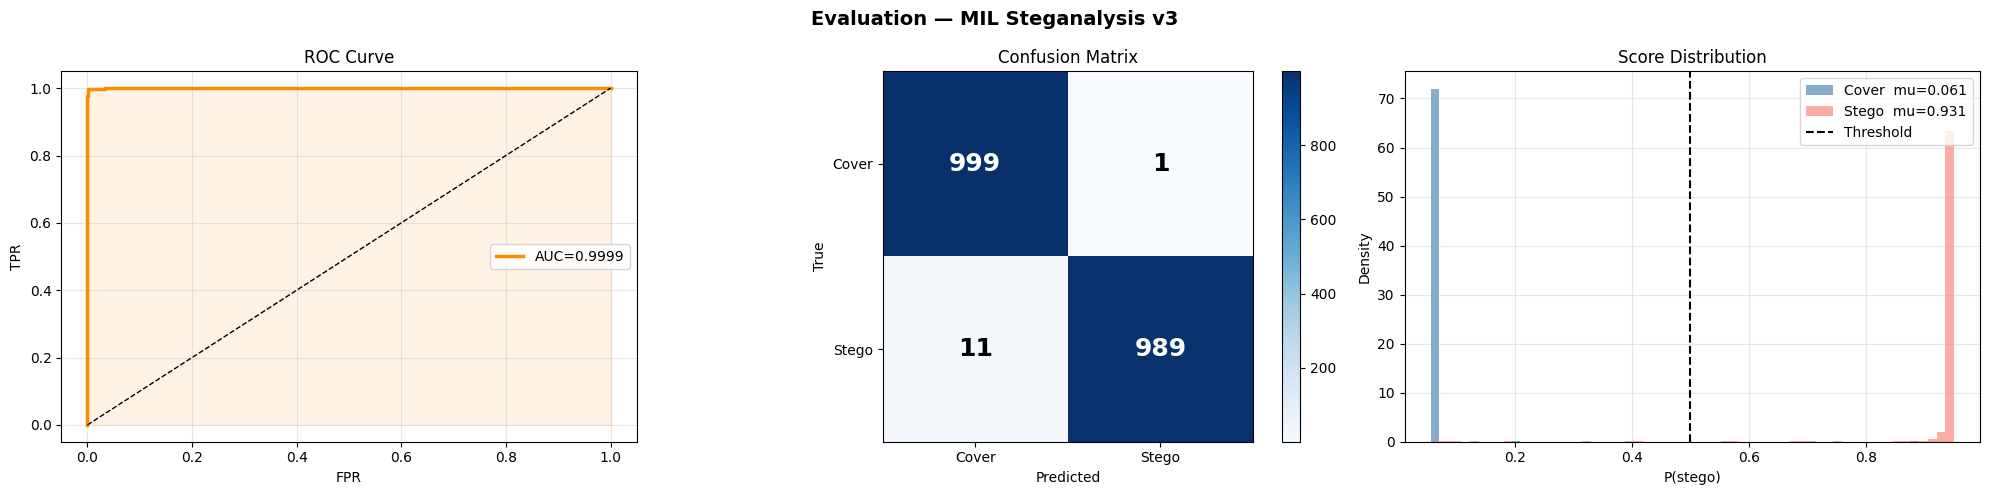

In [18]:
# Cell 16 — ROC curve, confusion matrix, score distribution
fpr, tpr, _ = roc_curve(all_labels, all_probs)
cover_sc = all_probs[all_labels==0]
stego_sc = all_probs[all_labels==1]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Evaluation — MIL Steganalysis v3', fontsize=14, fontweight='bold')

axes[0].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC={auc:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

im = axes[1].imshow(cm, cmap='Blues')
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Cover','Stego'])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(['Cover','Stego'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix')
thresh = cm.max()/2
for i in range(2):
    for j in range(2):
        axes[1].text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=18,
                     fontweight='bold',color='white' if cm[i,j]>thresh else 'black')

axes[2].hist(cover_sc, bins=60, alpha=0.65, color='steelblue',
             label=f'Cover  mu={cover_sc.mean():.3f}', density=True)
axes[2].hist(stego_sc, bins=60, alpha=0.65, color='salmon',
             label=f'Stego  mu={stego_sc.mean():.3f}', density=True)
axes[2].axvline(0.5, color='black', lw=1.5, linestyle='--', label='Threshold')
axes[2].set_xlabel('P(stego)'); axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CFG['results_dir'])/'evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

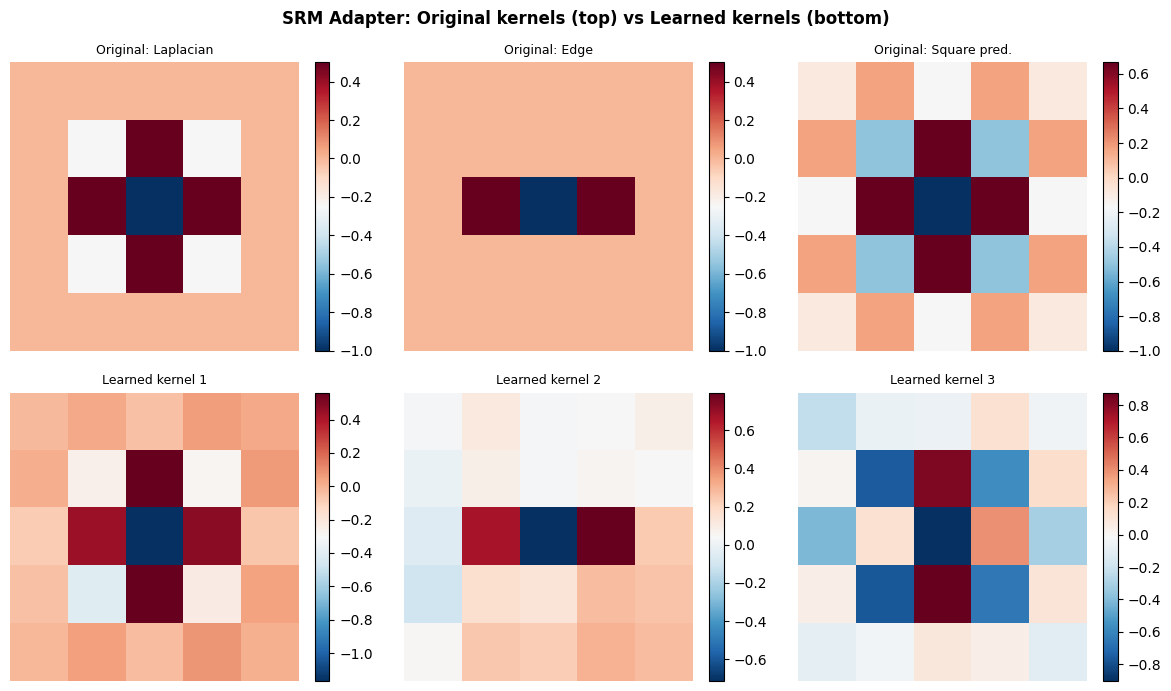

In [19]:
# Cell 17 — Visualise what the trainable SRM adapter learned vs original kernels
def show_learned_srm(model, save_path):
    learned  = model.srm.dw.weight.detach().cpu().numpy()  # (3,1,5,5)
    original = get_srm_init_weights().numpy()               # (3,1,5,5)
    names    = ['Laplacian', 'Edge', 'Square pred.']
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    fig.suptitle('SRM Adapter: Original kernels (top) vs Learned kernels (bottom)',
                 fontsize=12, fontweight='bold')
    for i in range(3):
        im0 = axes[0,i].imshow(original[i,0], cmap='RdBu_r')
        axes[0,i].set_title(f'Original: {names[i]}', fontsize=9)
        axes[0,i].axis('off'); plt.colorbar(im0, ax=axes[0,i], fraction=0.046)
        im1 = axes[1,i].imshow(learned[i,0],  cmap='RdBu_r')
        axes[1,i].set_title(f'Learned kernel {i+1}', fontsize=9)
        axes[1,i].axis('off'); plt.colorbar(im1, ax=axes[1,i], fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

show_learned_srm(model.cpu(), Path(CFG['results_dir'])/'learned_srm.png')
model = model.to(DEVICE)

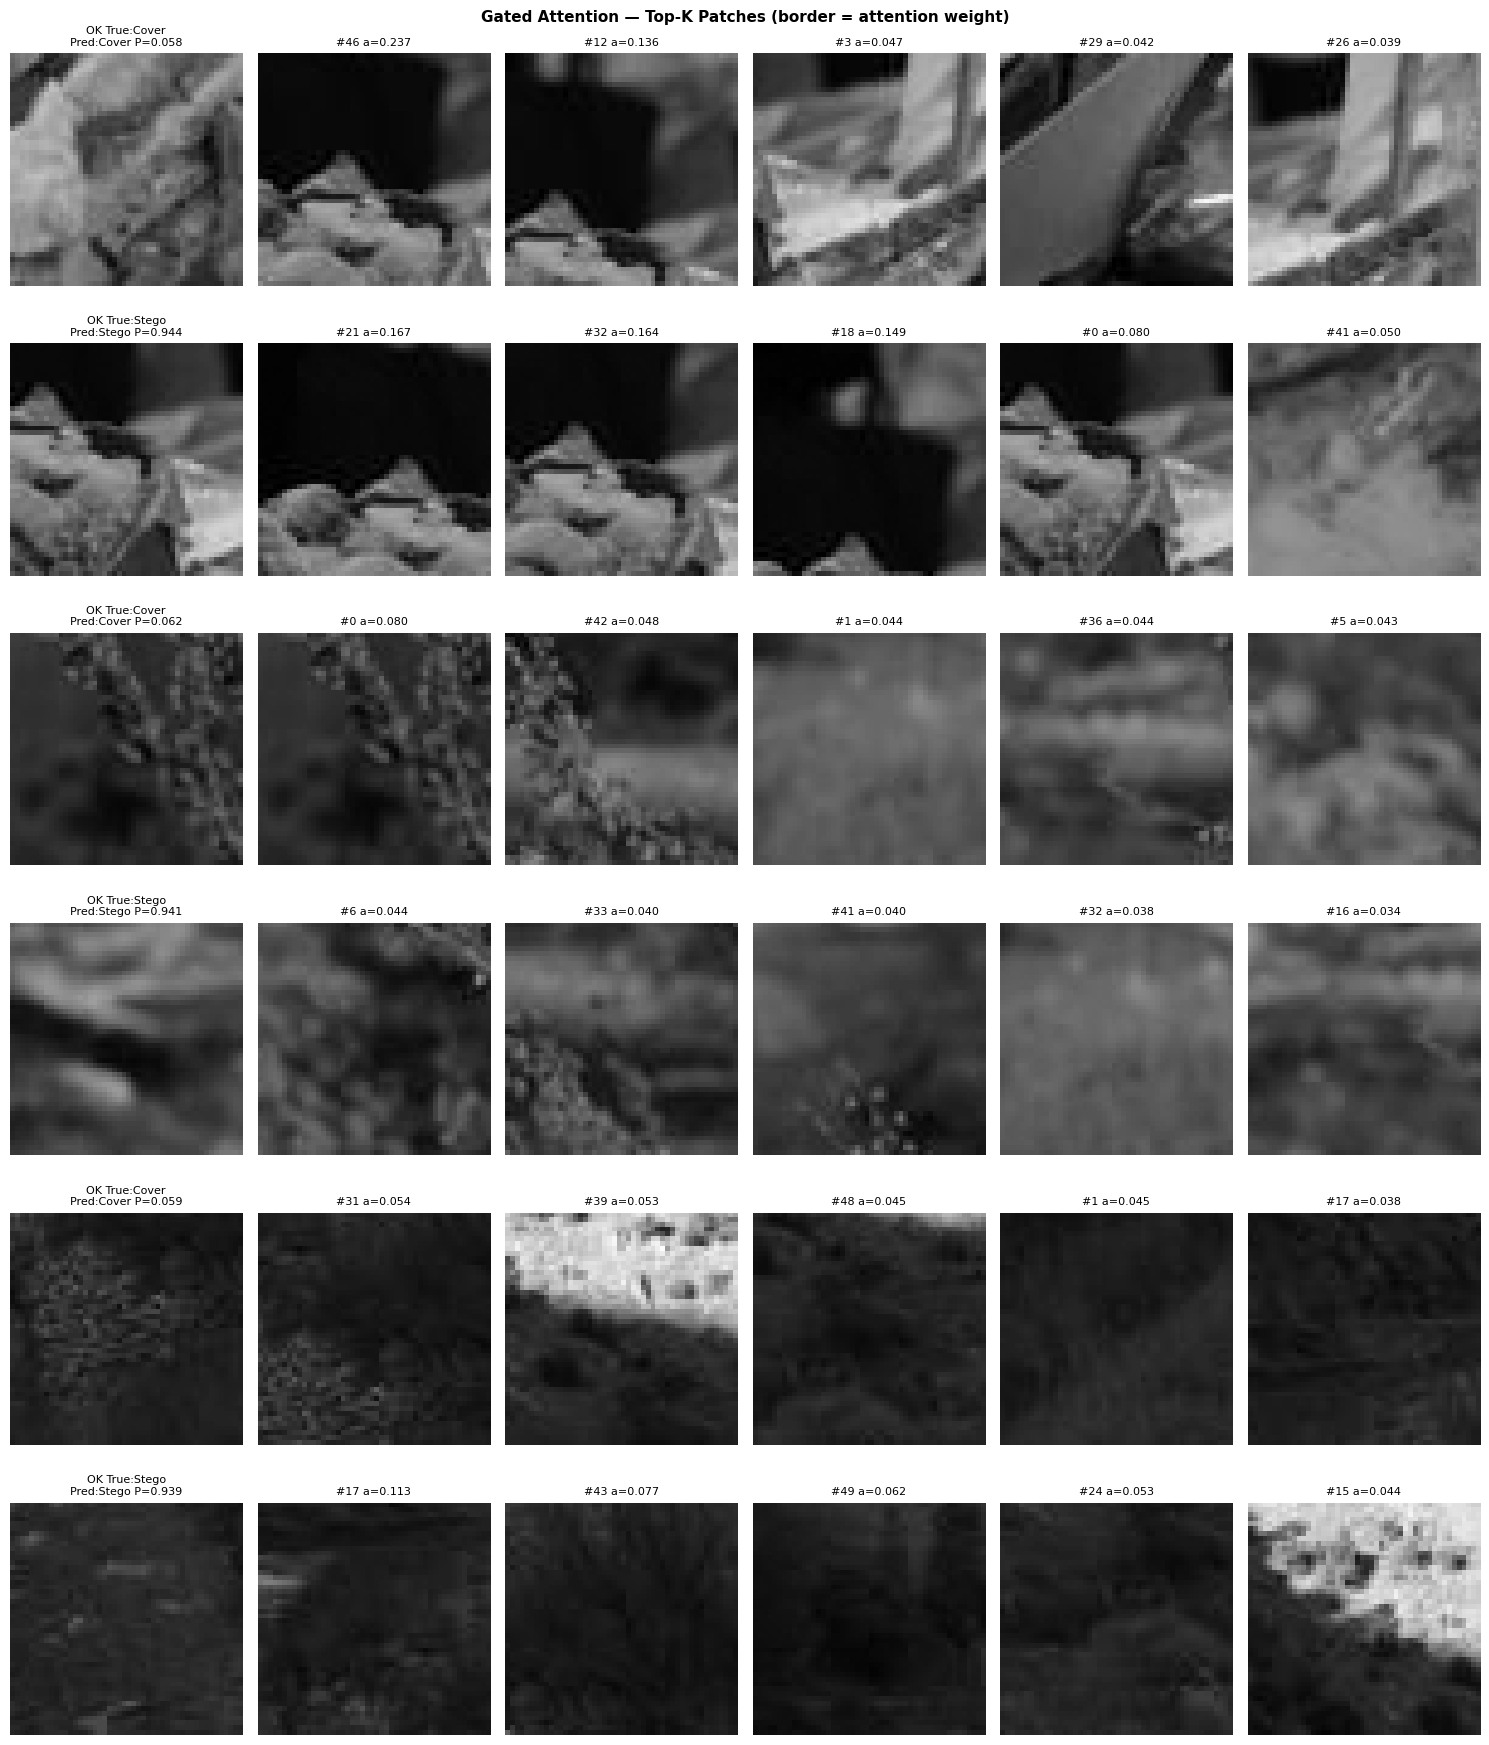

In [20]:
# Cell 18 — Gated attention visualisation
# Border redness = attention weight. High attention = model found patch suspicious.

def show_attention(model, dataset, indices, device, save_path, top_k=5):
    model.eval()
    n = len(indices)
    fig, axes = plt.subplots(n, top_k+1, figsize=((top_k+1)*2.5, n*3))
    if n == 1: axes = axes[np.newaxis,:]
    fig.suptitle('Gated Attention — Top-K Patches (border = attention weight)',
                 fontsize=11, fontweight='bold')
    for row, idx in enumerate(indices):
        bag, label = dataset[idx]
        with torch.no_grad(): logits, attn = model(bag.unsqueeze(0).to(device))
        prob  = torch.softmax(logits,dim=1)[0,1].item()
        attn  = attn[0].cpu().numpy()
        order = np.argsort(attn)[::-1]
        truth = 'Stego' if label.item()==1 else 'Cover'
        pred  = 'Stego' if prob>=0.5 else 'Cover'
        ok    = 'OK' if pred==truth else 'WRONG'
        axes[row,0].imshow(bag[0,0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row,0].set_title(f'{ok} True:{truth}\nPred:{pred} P={prob:.3f}', fontsize=8)
        axes[row,0].axis('off')
        for col, pi in enumerate(order[:top_k]):
            ax = axes[row, col+1]
            ax.imshow(bag[pi,0].numpy(), cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'#{pi} a={attn[pi]:.3f}', fontsize=8); ax.axis('off')
            intens = min(attn[pi]*CFG['num_patches']*0.8, 1.0)
            for sp in ax.spines.values():
                sp.set_edgecolor((intens,0.1,0.1)); sp.set_linewidth(2.5*intens+0.5); sp.set_visible(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()

_vis = StegDatasetV3(CFG['test_cover_dir'], CFG['test_stego_dir'],
                     common_test[:5], CFG['patch_size'], CFG['num_patches_test'], augment=False)
show_attention(model, _vis, list(range(min(6, len(_vis)))),
               DEVICE, Path(CFG['results_dir'])/'attention.png', top_k=5)

In [22]:
# Cell 19 — Export all artifacts for inference
export_dir = Path(CFG['export_dir'])
export_dir.mkdir(parents=True, exist_ok=True)

# 1. Best model checkpoint (CPU tensors)
ckpt = torch.load(
    Path(CFG['checkpoint_dir']) / 'best_model.pth',
    map_location='cpu',
    weights_only=False   # required for PyTorch 2.6+
)
model.load_state_dict(ckpt['model_state']); model.eval(); model.cpu()
torch.save({
    'epoch'        : ckpt['epoch'],
    'phase'        : ckpt['phase'],
    'auc'          : ckpt['auc'],
    'model_state'  : {k: v.cpu() for k, v in model.state_dict().items()},
    'architecture' : {
        'class'           : 'StegDetectorV3',
        'backbone_a'      : CFG['backbone_a'],
        'backbone_b'      : CFG['backbone_b'],
        'backbone_out_dim': CFG['backbone_out_dim'],
        'fused_dim'       : CFG['fused_dim'],
        'attn_hidden'     : CFG['attn_hidden'],
    },
}, export_dir / 'best_model.pth')
print('[1] best_model.pth saved')

# 2. TorchScript
try:
    dummy  = torch.randn(1, CFG['num_patches_test'], 3, CFG['patch_size'], CFG['patch_size'])
    traced = torch.jit.trace(model, dummy, strict=False)
    traced.save(str(export_dir / 'model_scripted.pt'))
    print('[2] model_scripted.pt saved')
except Exception as e:
    print(f'[2] TorchScript skipped: {e}')
model = model.to(DEVICE)

# 3. Inference config
inf_cfg = {
    'architecture'    : 'StegDetectorV3',
    'backbone_a'      : CFG['backbone_a'],
    'backbone_b'      : CFG['backbone_b'],
    'backbone_out_dim': CFG['backbone_out_dim'],
    'fused_dim'       : CFG['fused_dim'],
    'attn_hidden'     : CFG['attn_hidden'],
    'patch_size'      : CFG['patch_size'],
    'num_patches'     : CFG['num_patches_test'],
    'srm_location'    : 'inside_model_TrainableSRMAdapter',
    'input_format'    : 'raw grayscale replicated to 3ch float32 [0,1]',
    'data_note'       : 'Input must be lossless PNG. JPEG inputs will fail due to quantization noise.',
    'best_epoch'      : int(ckpt['epoch']),
    'best_phase'      : int(ckpt['phase']),
    'best_auc'        : float(ckpt['auc']),
    'checkpoint'      : 'best_model.pth',
}
with open(export_dir / 'inference_config.json', 'w') as f:
    json.dump(inf_cfg, f, indent=2)
print('[3] inference_config.json saved')

# 4. Copy results
for src in [Path(CFG['results_dir']) / 'metrics.json',
            Path(CFG['work_dir'])    / 'history.json']:
    if src.exists():
        shutil.copy2(src, export_dir / src.name)
for png in Path(CFG['results_dir']).glob('*.png'):
    shutil.copy2(png, export_dir / png.name)
print('[4] metrics, history, plots copied')

print('\nExport contents:')
for f in sorted(export_dir.iterdir()):
    print(f'  {f.name:<42}  {f.stat().st_size/1024:>8.1f} KB')

[1] best_model.pth saved
[2] model_scripted.pt saved
[3] inference_config.json saved
[4] metrics, history, plots copied

Export contents:
  attention.png                                  289.5 KB
  best_model.pth                              141546.7 KB
  evaluation.png                                 106.0 KB
  history.json                                     2.1 KB
  inference_config.json                            0.5 KB
  learned_srm.png                                 78.7 KB
  metrics.json                                     0.1 KB
  model_scripted.pt                           142892.2 KB
  training_curves.png                            158.2 KB


In [23]:
# Cell 20 — Final summary
print('=' * 62)
print('  MIL STEGANALYSIS v3 — FINAL RESULTS')
print('=' * 62)
print(f"  Data fix     : JPEG -> lossless PNG (diffs=[0,1] only)")
print(f"  Backbone A   : {CFG['backbone_a']}")
print(f"  Backbone B   : {CFG['backbone_b']}")
print(f"  SRM Adapter  : trainable (SRM-init 5x5 depthwise)")
print(f"  Attention    : Gated MIL (tanh x sigmoid)")
print(f"  Patch size   : {CFG['patch_size']}x{CFG['patch_size']} px")
print(f"  Bag size     : {CFG['num_patches']} train / {CFG['num_patches_test']} test")
print(f"  Total epochs : {CFG['phase3_end']}")
print(f"  Best epoch   : {best_epoch}  (Phase {ckpt['phase']})")
print('=' * 62)
print(f"  AUC-ROC      : {auc:.4f}")
print(f"  Accuracy     : {acc:.4f}")
print(f"  F1 Score     : {f1:.4f}")
print('=' * 62)
print('AUC guide:')
for lvl, lab in [(0.90,'Excellent'),(0.85,'Strong'),(0.80,'Good'),
                 (0.70,'Acceptable'),(0.60,'Weak'),(0.50,'Random')]:
    here = ' <- YOU ARE HERE' if lvl <= auc < lvl+0.05 else ''
    print(f'  {lvl:.2f}  {lab:<12}{here}')

  MIL STEGANALYSIS v3 — FINAL RESULTS
  Data fix     : JPEG -> lossless PNG (diffs=[0,1] only)
  Backbone A   : convnext_tiny
  Backbone B   : densenet121
  SRM Adapter  : trainable (SRM-init 5x5 depthwise)
  Attention    : Gated MIL (tanh x sigmoid)
  Patch size   : 48x48 px
  Bag size     : 32 train / 50 test
  Total epochs : 40
  Best epoch   : 16  (Phase 3)
  AUC-ROC      : 0.9999
  Accuracy     : 0.9940
  F1 Score     : 0.9940
AUC guide:
  0.90  Excellent   
  0.85  Strong      
  0.80  Good        
  0.70  Acceptable  
  0.60  Weak        
  0.50  Random      
